## Explore and visualize data v1

In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import os 
import json
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


In [4]:
# Load the JSON file line by line into a DataFrame
df = pd.read_csv("../data/export/dataset.csv")
df_finetuned = pd.read_csv("../data/export/fine-tuning-bert.csv")

In [3]:
df.head()

,speech_id,debate_id,amendment_author_name,amendment_author_group,amendment_content,amendment_summary,speech_date,speaker_name,speaker_group,speaker_government,label,speech
0,VTANR5L15V2035-15-754688,VTANR5L15V2035,Jean-Luc Mélenchon,FI,Compléter cet article par les trois alinéas su...,Cet amendement a pour objectif que les algorit...,2019-07-04,Danièle Obono,LFI,False,POUR,Il s’agit là d’un sujet que nous avons déjà év...
1,VTANR5L15V2035-15-754690,VTANR5L15V2035,Jean-Luc Mélenchon,FI,Compléter cet article par les trois alinéas su...,Cet amendement a pour objectif que les algorit...,2019-07-04,Laetitia Avia,LREM,False,CONTRE,Avis défavorable : comme je l’ai déjà dit en c...
2,VTANR5L15V2035-15-754692,VTANR5L15V2035,Jean-Luc Mélenchon,FI,Compléter cet article par les trois alinéas su...,Cet amendement a pour objectif que les algorit...,2019-07-04,Cédric O,LREM,True,CONTRE,La transparence des algorithmes est un enjeu d...
3,VTANR5L15V2035-15-754695,VTANR5L15V2035,Jean-Luc Mélenchon,FI,Compléter cet article par les trois alinéas su...,Cet amendement a pour objectif que les algorit...,2019-07-04,George Pau-Langevin,SOC,False,POUR,"Je voterai pour cet amendement, qui touche à u..."
4,VTANR5L15V2035-15-754697,VTANR5L15V2035,Jean-Luc Mélenchon,FI,Compléter cet article par les trois alinéas su...,Cet amendement a pour objectif que les algorit...,2019-07-04,Cédric O,LREM,True,CONTRE,Parmi les thèmes que le Gouvernement souhaite ...


In [5]:
df_finetuned.head()

,text
0,Les débats viennent à peine de commencer et je...
1,La question du financement des infrastructures...
2,"Avis défavorable. Il y a eu un Plom 1, désorma..."
3,Nous soutenons l’amendement n o 3837. Je voud...
4,"Je retire mon amendement, puisque nous y revie..."


In [6]:
# Check for missing values
print("Missing values in each column:")

for column in df.columns:
    missing_count = df[column].isnull().sum()
    print(f"{column}: {missing_count} missing values")

Missing values in each column:
speech_id: 0 missing values
debate_id: 0 missing values
amendment_author_name: 0 missing values
amendment_author_group: 0 missing values
amendment_content: 0 missing values
amendment_summary: 0 missing values
speech_date: 0 missing values
speaker_name: 1 missing values
speaker_group: 0 missing values
speaker_government: 0 missing values
label: 0 missing values
speech: 0 missing values


In [8]:
null_speaker_name = df[df['speaker_name'].isnull()]
null_speaker_name

,speech_id,debate_id,amendment_author_name,amendment_author_group,amendment_content,amendment_summary,speech_date,speaker_name,speaker_group,speaker_government,label,speech
6522,VTANR5L17V5314-17-68666,VTANR5L17V5314,Arnaud Saint-Martin,LFI-NFP,"Après l’alinéa 18, insérer l’alinéa suivant : ...","Par cet amendement, le groupe la France insoum...",2026-02-04,NaN,LREM,False,CONTRE,(Le vote à main levée n’ayant pas \n été concl...


In [9]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

Number of duplicate rows: 0


In [11]:
# Print range of speech_date
print(f"Range of speak dates: {df['speech_date'].min()} to {df['speech_date'].max()}")

Range of speak dates: 2017-07-11 to 2026-02-27


In [12]:
# Count unique values for each column
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"{column}: {unique_count} unique values")

speech_id: 7986 unique values
debate_id: 1758 unique values
amendment_author_name: 480 unique values
amendment_author_group: 31 unique values
amendment_content: 1623 unique values
amendment_summary: 1720 unique values
speech_date: 370 unique values
speaker_name: 804 unique values
speaker_group: 15 unique values
speaker_government: 2 unique values
label: 2 unique values
speech: 6701 unique values


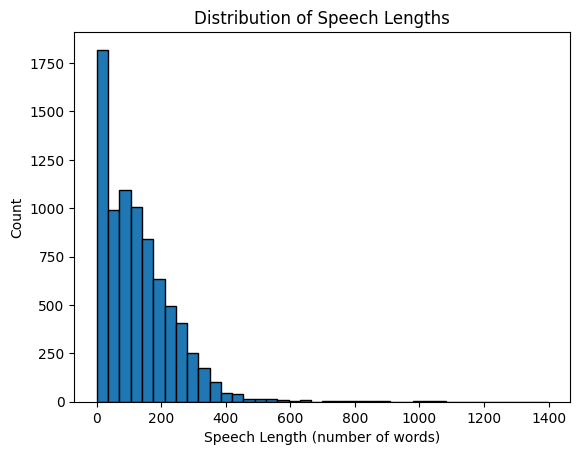

In [20]:
# Calculate speech length as number of words for each speech
df['speech_length'] = df['speech'].apply(lambda x: len(x.split()))

# Plot the distribution of speech lengths
plt.hist(df['speech_length'], bins=40, edgecolor='black')
plt.title('Distribution of Speech Lengths')
plt.xlabel('Speech Length (number of words)')
plt.ylabel('Count')
plt.show()


In [22]:
# more precisely, check for very short speeches (e.g., less than 10 words)
short_speeches = df[df['speech_length'] < 10]
print(f"Number of speeches with less than 10 words: {len(short_speeches)}")
short_speeches.head(20)

Number of speeches with less than 10 words: 1193


,speech_id,debate_id,amendment_author_name,amendment_author_group,amendment_content,amendment_summary,speech_date,speaker_name,speaker_group,speaker_government,label,speech,speech_length
21,VTANR5L15V531-15-569372,VTANR5L15V531,Bénédicte Taurine,FI,Substituer aux alinéas 2 à 12 l'alinéa suivant...,"Par cet amendement de repli, nous proposons de...",2018-04-21,Mathilde Panot,LFI,False,POUR,"Monsieur le président, faites votre travail !",7
26,VTANR5L15V1072-15-412625,VTANR5L15V1072,Cécile Untermaier,NG,L’article 25 de la Constitution est complété p...,Cet amendement vise à inscrire dans la Constit...,2018-07-18,Richard Ferrand,LREM,False,CONTRE,Avis défavorable.,2
39,VTANR5L15V527-15-745659,VTANR5L15V527,Éric Ciotti,LR,I. – Substituer aux alinéas 21 à 23 l'alinéa s...,Le présent amendement vise à rétablir la versi...,2018-04-21,Élise Fajgeles,LREM,False,CONTRE,Avis défavorable.,2
42,VTANR5L15V1176-15-45291,VTANR5L15V1176,Arnaud Viala,LR,"I. – À l’alinéa 44, substituer au mot : « cinq...",Le souhait d’assouplir les contraintes qui pès...,2018-09-27,Daniel Fasquelle,LR,False,POUR,Il est défendu.,3
43,VTANR5L15V1176-15-45293,VTANR5L15V1176,Arnaud Viala,LR,"I. – À l’alinéa 44, substituer au mot : « cinq...",Le souhait d’assouplir les contraintes qui pès...,2018-09-27,Denis Sommer,LREM,False,CONTRE,Avis défavorable.,2
44,VTANR5L15V1176-15-45295,VTANR5L15V1176,Arnaud Viala,LR,"I. – À l’alinéa 44, substituer au mot : « cinq...",Le souhait d’assouplir les contraintes qui pès...,2018-09-27,Bruno Le Maire,LREM,True,CONTRE,Avis défavorable.,2
59,VTANR5L15V1199-15-202667,VTANR5L15V1199,Dominique Potier,SOC,Rédiger ainsi cet article : « I. – L’article L...,"Depuis une trentaine d’années, le mouvement de...",2018-10-05,Dominique Potier,SOC,False,POUR,"Oui, monsieur le président.",4
68,VTANR5L15V788-15-907903,VTANR5L15V788,François Pupponi,NG,Compléter l’alinéa 59 par la phrase suivante :...,Le présent amendement vise à éviter les abus d...,2018-06-03,Christelle Dubos,LREM,False,CONTRE,Défavorable.,1
69,VTANR5L15V788-15-907905,VTANR5L15V788,François Pupponi,NG,Compléter l’alinéa 59 par la phrase suivante :...,Le présent amendement vise à éviter les abus d...,2018-06-03,Jacques Mézard,LREM,True,CONTRE,Défavorable.,1
85,VTANR5L15V3425-15-767757,VTANR5L15V3425,Agnès Firmin Le Bodo,AGIR-E,Le dernier alinéa de l’article L. 4624‑2‑1 du ...,: Un amendement visant à créer une visite méd...,2021-02-16,Carole Grandjean,LREM,False,CONTRE,"Demande de retrait ; à défaut, avis défavorable.",8


In [25]:
# Check if some speaker_name have a change in there affilliation to	speaker_group
speaker_group_changes = df.groupby('speaker_name')['speaker_group'].nunique()
speakers_with_changes = speaker_group_changes[speaker_group_changes > 1]
print(f"Number of speakers with changes in speaker_group: {len(speakers_with_changes)}")


# For each speaker with changes, show their different groups and the first/last speech_date for each group
result = (
    df[df['speaker_name'].isin(speakers_with_changes.index)]
    .groupby(['speaker_name', 'speaker_group'])['speech_date']
    .agg(['min', 'max'])
    .reset_index()
)

# Show only the first 10 speakers with changes for brevity
for speaker in speakers_with_changes.index[:10]:
    print(f"\nSpeaker: {speaker}")
    display(result[result['speaker_name'] == speaker])

Number of speakers with changes in speaker_group: 47

Speaker: Agnès Firmin Le Bodo


,speaker_name,speaker_group,min,max
0,Agnès Firmin Le Bodo,AGIR-E,2020-10-08,2021-02-16
1,Agnès Firmin Le Bodo,HOR,2023-12-07,2026-02-19
2,Agnès Firmin Le Bodo,UDI,2017-11-23,2019-02-14



Speaker: Albane Gaillot


,speaker_name,speaker_group,min,max
3,Albane Gaillot,EDS,2020-10-08,2020-10-08
4,Albane Gaillot,LREM,2019-03-22,2019-03-22



Speaker: Alexis Corbière


...

,speaker_name,speaker_group,min,max
16,Béatrice Piron,HOR,2025-05-05,2025-05-05
17,Béatrice Piron,LREM,2023-04-13,2023-04-13



Speaker: Charles de Courson


,speaker_name,speaker_group,min,max
18,Charles de Courson,LIOT,2019-12-04,2025-06-24
19,Charles de Courson,UDI,2018-09-19,2018-09-19



Speaker: Charlotte Parmentier-Lecocq


,speaker_name,speaker_group,min,max
20,Charlotte Parmentier-Lecocq,HOR,2025-05-05,2026-01-29
21,Charlotte Parmentier-Lecocq,LREM,2022-07-18,2022-07-18


### Split train/test set 

In [ ]:
# Randomly split the df into two separate dataframes, one for training (85%) and one for testing (15%).
train_df = df.sample(frac=0.85, random_state=42)
test_df = df.drop(train_df.index)
print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")

# print the distribution of speaker groups, and labels in the training and testing sets
print("Distribution of speaker groups in the training set:")
print(train_df['speaker_group'].value_counts(normalize=True))
print("\nDistribution of labels in the training set:")
print(train_df['label'].value_counts(normalize=True))
print("\nDistribution of speaker groups in the testing set:")
print(test_df['speaker_group'].value_counts(normalize=True)) 
print("\nDistribution of labels in the testing set:")
print(test_df['label'].value_counts(normalize=True))  


Training set size: 6788
Testing set size: 1198
Distribution of speaker groups in the training set:
speaker_group
LREM      0.346346
LFI       0.140395
LR        0.098556
RN        0.087360
SOC       0.074691
MODEM     0.073807
ECOLO     0.047289
GDR       0.036830
HOR       0.035504
LIOT      0.034620
UDI       0.012375
UDR       0.006629
NI        0.004125
AGIR-E    0.001326
EDS       0.000147
Name: proportion, dtype: float64

Distribution of labels in the training set:
label
CONTRE    0.50604
POUR      0.49396
Name: proportion, dtype: float64

Distribution of speaker groups in the testing set:
speaker_group
LREM     0.361436
LFI      0.139399
LR       0.104341
RN       0.085977
SOC      0.069282
MODEM    0.059265
HOR      0.042571
GDR      0.040902
ECOLO    0.040067
LIOT     0.029215
UDI      0.013356
UDR      0.008347
NI       0.005008
EDS      0.000835
Name: proportion, dtype: float64

Distribution of labels in the testing set:
label
CONTRE    0.506678
POUR      0.493322
Name: prop

In [8]:
# output the test and training sets to csv files
train_df.to_csv("../data/export/train_dataset.csv", index=False)
test_df.to_csv("../data/export/test_dataset.csv", index=False)

## Analyze results

In [31]:
qwen_results = pd.read_csv("../data/eval_testset_qwen.csv")
qwen_results_amend = pd.read_csv("../data/eval_testset_qwen_amend.csv")

In [36]:
print('Distribution of predicted labels in the qwen results:')
print(qwen_results['predicted_label'].value_counts(normalize=True))
print('Distribution of predicted labels in the qwen results amend:')
print(qwen_results_amend['predicted_label'].value_counts(normalize=True))

Distribution of predicted labels in the qwen results:
predicted_label
0    0.74374
1    0.25626
Name: proportion, dtype: float64
Distribution of predicted labels in the qwen results amend:
predicted_label
 0    0.780467
 1    0.218698
-1    0.000835
Name: proportion, dtype: float64


In [37]:
qwen_results['true_label'] = qwen_results['label'].map({'CONTRE': 0, 'POUR': 1})
qwen_results_amend['true_label'] = qwen_results_amend['label'].map({'CONTRE': 0, 'POUR': 1})

In [19]:
qwen_results

,speech_id,debate_id,amendment_author_name,amendment_author_group,amendment_content,amendment_summary,speech_date,speaker_name,speaker_group,speaker_government,label,speech,predicted_label,llm_output,true_label
0,VTANR5L15V2035-15-754697,VTANR5L15V2035,Jean-Luc Mélenchon,FI,Compléter cet article par les trois alinéas su...,Cet amendement a pour objectif que les algorit...,2019-07-04,Cédric O,LREM,True,CONTRE,Parmi les thèmes que le Gouvernement souhaite ...,1,Position: POUR,0
1,VTANR5L15V423-15-669761,VTANR5L15V423,Bastien Lachaud,FI,"À l’alinéa 103, supprimer les mots : « ou de c...",Le présent amendement vise à exclure la « cont...,2018-03-21,Jean-Luc Mélenchon,LFI,False,POUR,Nous venons d’entendre Mme la ministre et nous...,0,Position: CONTRE,1
2,VTANR5L15V1137-15-845948,VTANR5L15V1137,Loïc Prud'homme,FI,"Compléter l’alinéa 7 par les mots : « , en pri...","Selon nous, la question à laquelle doit répond...",2018-09-14,Jean-Luc Mélenchon,LFI,False,POUR,"J’avoue être assez stupéfait, madame Pompili, ...",0,Position: CONTRE,1
3,VTANR5L15V1208-15-778472,VTANR5L15V1208,Daniel Fasquelle,LR,Supprimer cet article.,L’article 71 habilite le gouvernement à légifé...,2018-10-05,Coralie Dubost,LREM,False,CONTRE,L’article 71 ter est issu d’un amendement dé...,0,Position: CONTRE,0
4,VTANR5L15V1199-15-202657,VTANR5L15V1199,Dominique Potier,SOC,Rédiger ainsi cet article : « I. – L’article L...,"Depuis une trentaine d’années, le mouvement de...",2018-10-05,Coralie Dubost,LREM,False,CONTRE,Nous sommes particulièrement fiers de renforce...,0,Position: CONTRE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,VTANR5L17V5542-17-62989,VTANR5L17V5542,Patrick Hetzel,DR,Compléter cet article par les deux alinéas sui...,L’aide à mourir est incompatible avec les disp...,2026-02-19,Brigitte Liso,LREM,False,CONTRE,Ces amendements sont superfétatoires car il n’...,0,Position: CONTRE,0
1194,VTANR5L17V1852-17-72976,VTANR5L17V1852,Justine Gruet,DR,Rédiger ainsi l’alinéa 9 : « 5° Exprimer son c...,Cet amendement vise à s’assurer que le consent...,2025-05-19,Justine Gruet,LR,False,POUR,Afin de sécuriser le consentement libre et écl...,0,Position: CONTRE,1
1195,VTANR5L17V956-17-165823,VTANR5L17V956,Géraldine Grangier,RN,"I. – À l’alinéa 2, après le mot : « peut », i...",Cet amendement vise à clarifier l'exercice du ...,2025-03-11,Peio Dufau,SOC,False,CONTRE,Défavorable.,0,Position: CONTRE,0
1196,VTANR5L17V1043-17-205637,VTANR5L17V1043,Ugo Bernalicis,LFI-NFP,"I. – Après l’alinéa 16, insérer l’alinéa suiva...","Par cet amendement d'appel, les député.es du g...",2025-03-18,Vincent Caure,LREM,False,CONTRE,Vous vous inquiétez de la répartition des comp...,0,Position: CONTRE,0


In [46]:

def compute_eval_metrics(df, model_prompt):

    # 1. Filter out invalid predictions (-1)
    valid = df[df["predicted_label"] != -1]

    y_true = valid["true_label"]
    y_pred = valid["predicted_label"]

    # 2. Compute metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)    

    # --- Error breakdown ---
    errors = (y_true != y_pred)
    n_errors = errors.sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp_pct = fp / n_errors if n_errors > 0 else 0
    fn_pct = fn / n_errors if n_errors > 0 else 0

    # --- Class-wise F1 ---
    f1_pos = f1_score(y_true, y_pred, pos_label=1)
    f1_neg = f1_score(y_true, y_pred, pos_label=0)

    
    # Return as a DataFrame row
    return pd.DataFrame([{
        "model_prompt": model_prompt,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "accuracy": accuracy,
        "f1_pour(1)": f1_pos,
        "f1_contre(0)": f1_neg,
        "fp_pct_errors": fp_pct,
        "fn_pct_errors": fn_pct,
        "n_errors": n_errors,
        "n_samples": len(valid),
        "n_total": len(df)
    }])

In [47]:
res_df = compute_eval_metrics(qwen_results, "Qwen2.5-7B (zero-shot / no context)") 
res_amend_df = compute_eval_metrics(qwen_results_amend, "Qwen2.5-7B (zero-shot / amendment context)") 

In [48]:
res_df

,model_prompt,precision,recall,f1_score,accuracy,f1_pour(1),f1_contre(0),fp_pct_errors,fn_pct_errors,n_errors,n_samples,n_total
0,Qwen2.5-7B (zero-shot / no context),0.830619,0.431472,0.567929,0.676127,0.567929,0.740988,0.134021,0.865979,388,1198,1198


In [49]:
res_amend_df

,model_prompt,precision,recall,f1_score,accuracy,f1_pour(1),f1_contre(0),fp_pct_errors,fn_pct_errors,n_errors,n_samples,n_total
0,Qwen2.5-7B (zero-shot / amendment context),0.889313,0.394247,0.546307,0.676692,0.546307,0.748864,0.074935,0.925065,387,1197,1198


In [24]:
errors = qwen_results[qwen_results['true_label'] != qwen_results['predicted_label']]


In [43]:
errors

,speech_id,debate_id,amendment_author_name,amendment_author_group,amendment_content,amendment_summary,speech_date,speaker_name,speaker_group,speaker_government,label,speech,predicted_label,llm_output,true_label
0,VTANR5L15V2035-15-754697,VTANR5L15V2035,Jean-Luc Mélenchon,FI,Compléter cet article par les trois alinéas su...,Cet amendement a pour objectif que les algorit...,2019-07-04,Cédric O,LREM,True,CONTRE,Parmi les thèmes que le Gouvernement souhaite ...,1,Position: POUR,0
1,VTANR5L15V423-15-669761,VTANR5L15V423,Bastien Lachaud,FI,"À l’alinéa 103, supprimer les mots : « ou de c...",Le présent amendement vise à exclure la « cont...,2018-03-21,Jean-Luc Mélenchon,LFI,False,POUR,Nous venons d’entendre Mme la ministre et nous...,0,Position: CONTRE,1
2,VTANR5L15V1137-15-845948,VTANR5L15V1137,Loïc Prud'homme,FI,"Compléter l’alinéa 7 par les mots : « , en pri...","Selon nous, la question à laquelle doit répond...",2018-09-14,Jean-Luc Mélenchon,LFI,False,POUR,"J’avoue être assez stupéfait, madame Pompili, ...",0,Position: CONTRE,1
6,VTANR5L15V35-15-99628,VTANR5L15V35,Pierre Dharréville,GDR,"Après l’article L. 5312‑1 du code du travail, ...",Cet amendement a pour objet de favoriser l’emp...,2017-07-13,Jean-Paul Lecoq,GDR,False,POUR,"Madame la ministre, je veux bien entendre que ...",0,Position: CONTRE,1
9,VTANR5L15V771-15-958208,VTANR5L15V771,Stéphane Peu,GDR,"À la première phrase de l’alinéa 20, après le ...",La rédaction actuelle de l’article L. 443-7 pe...,2018-06-03,Stéphane Peu,GDR,False,POUR,"Défendu ! Je voudrais bien en dire plus, mais ...",0,Position: CONTRE,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,VTANR5L17V5597-17-329254,VTANR5L17V5597,Élise Leboucher,LFI-NFP,Compléter cet article par les deux alinéas sui...,Cet amendement vise à permettre la prise en co...,2026-02-20,Élise Leboucher,LFI,False,POUR,"Avant de présenter l’amendement, je souhaite r...",0,Position: CONTRE,1
1187,VTANR5L17V1686-17-271947,VTANR5L17V1686,Vincent Jeanbrun,DR,Compléter l'alinéa 2 par les mots : « ou de d...,Cet amendement du groupe Droite Républicaine v...,2025-05-15,Valérie Létard,LIOT,True,POUR,La mobilisation à titre temporaire du disposit...,0,Position: CONTRE,1
1191,VTANR5L17V2287-17-39150,VTANR5L17V2287,Claire Lejeune,LFI-NFP,Supprimer cet article.,"Par cet amendement, les député.es du groupe LF...",2025-06-13,Claire Lejeune,LFI,False,POUR,Pour l’ensemble des raisons qui viennent d’êtr...,0,Position: CONTRE,1
1192,VTANR5L17V2287-17-39153,VTANR5L17V2287,Claire Lejeune,LFI-NFP,Supprimer cet article.,"Par cet amendement, les député.es du groupe LF...",2025-06-13,Stéphane Travert,LREM,False,CONTRE,Vous me permettrez de prendre quelques minutes...,1,Position: POUR,0


In [45]:
for i, row in errors.head(10).iterrows():
    print(f"Amendement: {row['amendment_summary']}")
    print(f"Speech: {row['speech']}")
    print(f"True Label: {row['true_label']}, Predicted Label: {row['predicted_label']}")
    print("-" * 50)

Amendement: Cet amendement a pour objectif que les algorithmes utilisés par les plateformes n’aient pas pour conséquence de perpétuer, de produire ou de renforcer des préjugés justifiant et instituant des discriminations entre les personnes en raison de ce qu’elles sont.  Plusieurs études l’ont montré, les grosses plateformes, dont nous avons souvent un usage quotidien, ne sont pas exemptes des structures de discriminations existant historiquement et socialement dans notre société. C’est ce qu’a analysé l’ancienne analyste de Wall Street, Cathy O’Neil, dans son ouvrage « Weapons of Math destruction » , préfacé dans sa version française par le député et mathématicien Cédric Villani, qui a souligné la justesse de ses analyses. Elle y démontre notamment que derrière l’objectivité et la neutralité proclamée des algorithmes du fait de leur fonctionnement mathématique se cache en réalité les opinions et intérêts subjectifs des personnes les créant ou les utilisant. De même, dans « Algorithms